In [1]:
from RK.ide import ide_solve
from math   import exp, sin, cos, pi, log, log10
import numpy as np
import matplotlib.pyplot as plt

## Example 1 (only integral)

y_end =  148.41315925335257


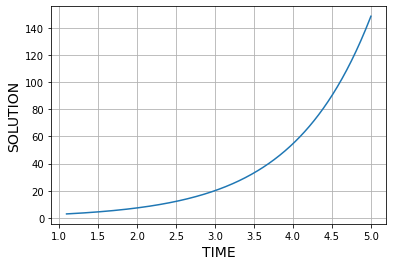

Convergence order: 3.9992668662883673


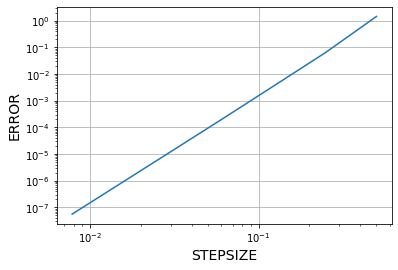

In [2]:
tspan      = [1.1, 5]
idefun     = lambda t,y,z,i: ((t-1)*exp(t*t)*i)/(exp(-1)*y-1)
K          = lambda t,s,y:   [y*exp(-s*t)]
delays     = lambda t,y:     [t-1] # delays of z
delays_int = lambda t:       [t-1] # delays of integrals
history    = lambda t:       exp(t)

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][-1])

fig1 = plt.subplots()
plt.plot(sol[0], sol[1])
plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()

def fun1(t):
    return exp(t)
true_sol   = fun1(tspan[1])

nb = 1; n = 8
err = []; nsteps = []

for steppow in range(nb,n):
    stepsize = pow(2,-steppow)
    sol = ide_solve(idefun,delays,K,delays_int,history,tspan,stepsize)
    err.append(abs(true_sol - sol[1][-1]))
    nsteps.append(stepsize)

print("Convergence order:",(log10(err[-1])-log10(err[-2]))/(log10(pow(2,-n))-log10(pow(2,-n+1))))

fig2 = plt.subplots()
plt.plot(nsteps,err)
plt.xscale('log'); plt.yscale('log'); plt.xlabel("STEPSIZE", fontsize=14); plt.ylabel("ERROR", fontsize=14); plt.grid()
plt.show()

## Example 2 (integral+discrete delays)

y_end =  -0.8390715237122065


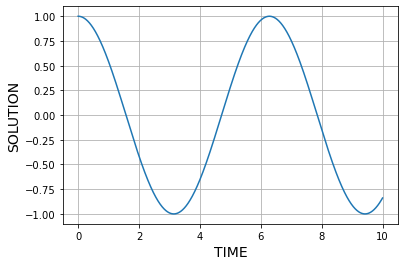

Convergence order: 3.9714186205724546


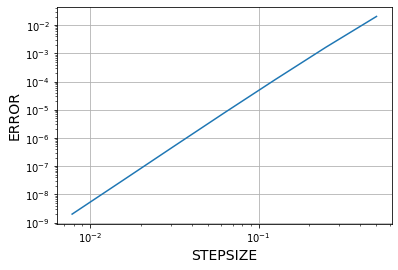

In [3]:
tspan      = [0, 10]
idefun     = lambda t,y,z,i: (1+exp(-pi/2))*y-exp(-pi/2)*z-2*exp(-2*t)*i
K          = lambda t,s,y:   [y*exp(t+s)]
delays     = lambda t,y:     [t-pi/2] # delays of z
delays_int = lambda t:       [t-pi/2] # delays of integrals
history    = lambda t:       cos(t)

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][-1])

fig1 = plt.subplots()
plt.plot(sol[0], sol[1])
plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()

def fun1(t):
    return cos(t)
true_sol   = fun1(tspan[1])

nb = 1; n = 8
err = []; nsteps = []

for steppow in range(nb,n):
    stepsize = pow(2,-steppow)
    sol = ide_solve(idefun,delays,K,delays_int,history,tspan,stepsize)
    err.append(abs(true_sol - sol[1][-1]))
    nsteps.append(stepsize)

print("Convergence order:",(log10(err[-1])-log10(err[-2]))/(log10(pow(2,-n))-log10(pow(2,-n+1))))

fig2 = plt.subplots()
plt.plot(nsteps,err)
plt.xscale('log'); plt.yscale('log'); plt.xlabel("STEPSIZE", fontsize=14); plt.ylabel("ERROR", fontsize=14); plt.grid()
plt.show()

## Example 3 (integral+discrete delays+overlapping)

y_end =  0.0067379469814580545


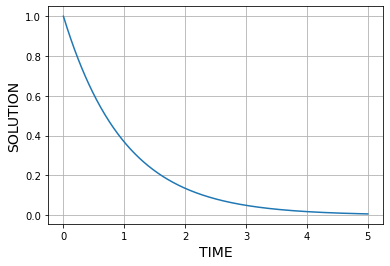

Convergence order: 3.990752239130475


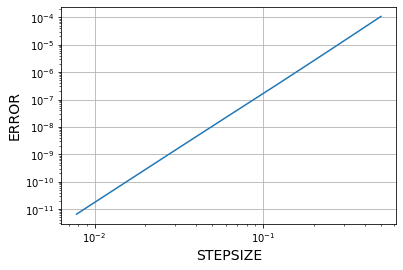

In [4]:
tspan      = [0, 5]
idefun     = lambda t,y,z,i: -y*y-t*exp(t*t)*pow(z,4)*i
K          = lambda t,s,y:   [y*exp(s-s*t)]
delays     = lambda t,y:     [t/2] # delays of z
delays_int = lambda t:       [t-1] # delays of integrals
history    = lambda t:       exp(-t)

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][-1])

fig1 = plt.subplots()
plt.plot(sol[0], sol[1])
plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()

def fun1(t):
    return exp(-t)
true_sol   = fun1(tspan[1])

nb = 1; n = 8
err = []; nsteps = []

for steppow in range(nb,n):
    stepsize = pow(2,-steppow)
    sol = ide_solve(idefun,delays,K,delays_int,history,tspan,stepsize)
    err.append(abs(true_sol - sol[1][-1]))
    nsteps.append(stepsize)

print("Convergence order:",(log10(err[-1])-log10(err[-2]))/(log10(pow(2,-n))-log10(pow(2,-n+1))))

fig2 = plt.subplots()
plt.plot(nsteps,err)
plt.xscale('log'); plt.yscale('log'); plt.xlabel("STEPSIZE", fontsize=14); plt.ylabel("ERROR", fontsize=14); plt.grid()
plt.show()

## Example 4 (2 integrals)

y_end =  148.41315915325342


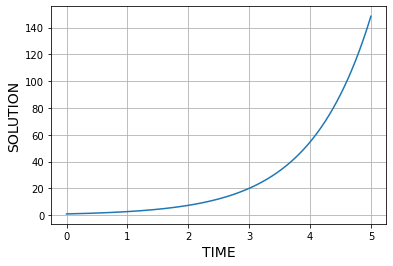

Convergence order: 3.98591321803516


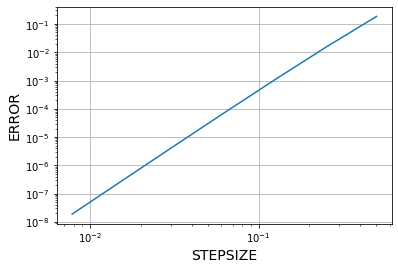

In [5]:
tspan      = [0, 5];
idefun     = lambda t,y,z,i: exp(1)-exp(t*t)/(z*z)*(i[0]-exp(-2*t)*i[1])*(t-1)
K          = lambda t,s,y:  [y*exp(-s*t),
                             y*exp(t*(2-s))]
delays     = lambda t,y:    [t-1] # delays of z
delays_int = lambda t:      [t-1,
                             t-2] # delays of integrals
history    = lambda t:       exp(t)

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][-1])

fig1 = plt.subplots()
plt.plot(sol[0], sol[1])
plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()

def fun1(t):
    return exp(t)
true_sol   = fun1(tspan[1])

nb = 1; n = 8
err = []; nsteps = []

for steppow in range(nb,n):
    stepsize = pow(2,-steppow)
    sol = ide_solve(idefun,delays,K,delays_int,history,tspan,stepsize)
    err.append(abs(true_sol - sol[1][-1]))
    nsteps.append(stepsize)

print("Convergence order:",(log10(err[-1])-log10(err[-2]))/(log10(pow(2,-n))-log10(pow(2,-n+1))))

fig2 = plt.subplots()
plt.plot(nsteps,err)
plt.xscale('log'); plt.yscale('log'); plt.xlabel("STEPSIZE", fontsize=14); plt.ylabel("ERROR", fontsize=14); plt.grid()
plt.show()

## Example 5 (2 discrete delays)

y_end =  0.006737947029428378


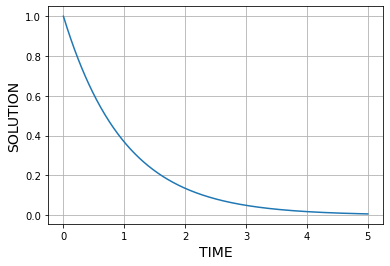

Convergence order: 4.03407558307881


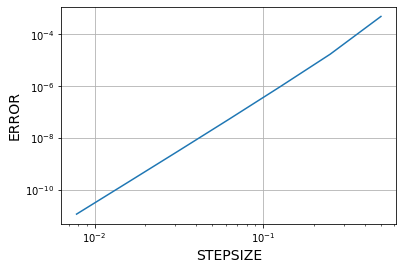

In [6]:
tspan      = [0, 5];
idefun     = lambda t,y,z,i: -pow(z[0],(t+1)/2) * z[1] * y*y * (1+exp(t*t)*t*i) / exp(1/2)
K          = lambda t,s,y:   [y*exp(s-s*t)]
delays     = lambda t,y:     [ pow(log(y),2) / (t+1) - 1/2,
                               (t-1)/4 ]
delays_int = lambda t:       [t/2-1]
history    = lambda t:       exp(-t)

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][-1])

fig1 = plt.subplots()
plt.plot(sol[0], sol[1])
plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()

def fun1(t):
    return exp(-t)
true_sol   = fun1(tspan[1])

nb = 1; n = 8
err = []; nsteps = []

for steppow in range(nb,n):
    stepsize = pow(2,-steppow)
    sol = ide_solve(idefun,delays,K,delays_int,history,tspan,stepsize)
    err.append(abs(true_sol - sol[1][-1]))
    nsteps.append(stepsize)

print("Convergence order:",(log10(err[-1])-log10(err[-2]))/(log10(pow(2,-n))-log10(pow(2,-n+1))))

fig2 = plt.subplots()
plt.plot(nsteps,err)
plt.xscale('log'); plt.yscale('log'); plt.xlabel("STEPSIZE", fontsize=14); plt.ylabel("ERROR", fontsize=14); plt.grid()
plt.show()

## Examples (Yukihiko)

y_end =  -2.0422322798209653


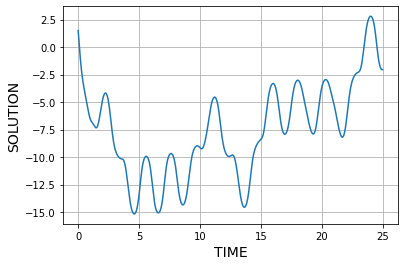

In [7]:
tspan      = [0, 25]
idefun     = lambda t,y,z,i: -15*i
K          = lambda t,s,y:   [sin(y)]
delays     = lambda t,y:     [t-1] # delays of z
delays_int = lambda t:       [t-1] # delays of integrals
history    = lambda t:       1.5

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][-1])

fig = plt.subplots()
plt.plot(sol[0], sol[1])
plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()

y_end =  -2.0422322798209653
y_end =  -1.2167450865667744
y_end =  8.176591500707333e-07


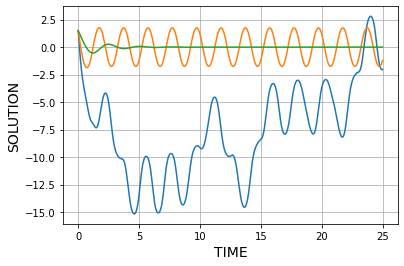

In [8]:
tspan      = [0, 25]
idefun     = lambda t,y,z,i: -15*i
K          = lambda t,s,y:   [sin(y)]
delays     = lambda t,y:     [t-1] # delays of z
delays_int = lambda t:       [t-1] # delays of integrals
history    = lambda t:       1.5

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][-1])

fig = plt.subplots()
plt.plot(sol[0], sol[1])

idefun     = lambda t,y,z,i: -7.5*i
sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)
plt.plot(sol[0], sol[1])
print("y_end = ", sol[1][-1])

idefun     = lambda t,y,z,i: -2.5*i
sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)
plt.plot(sol[0], sol[1])
print("y_end = ", sol[1][-1])

plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()

## Example 6-7 (system of equations) (!!! IN WORK !!!)

In [9]:
tspan      = [0, 10];
idefun     = lambda t,y,z,i: [ -2.5*i[0],
                               -15*i[1],
                               0.001*exp(t)]
K          = lambda t,s,y:  [  sin(y[0]),
                               sin(y[1])]
delays     = lambda t,y:    [t-1] # delays of z
delays_int = lambda t:      [t-1,
                             t-1] # delays of integrals
history    = lambda t:      [ 1.5,
                              1.5,
                              0.001*exp(t)]

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][:,-1])

fig1 = plt.subplots()
for i in range(np.size(history(tspan[0]))):
    plt.plot(sol[0], sol[1][i])
plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()

ValueError: setting an array element with a sequence.

In [10]:
tspan      = [0, 25];
idefun     = lambda t,y,z,i: [ -2.5*i[0],
                               -7.5*i[1],
                               -15*i[2]]
K          = lambda t,s,y:  [  sin(y[0]),
                               sin(y[1]),
                               sin(y[2])]
delays     = lambda t,y:     [t-1] # delays of z
delays_int = lambda t:      [t-1,
                             t-1,
                             t-1] # delays of integrals
history    = lambda t:      [ 1.5,
                              1.5,
                              1.5]

sol = ide_solve(idefun,delays,K,delays_int,history,tspan,1e-2)

print("y_end = ", sol[1][:,-1])

fig1 = plt.subplots()
for i in range(np.size(history(tspan[0]))):
    plt.plot(sol[0], sol[1][i])
plt.xlabel("TIME", fontsize=14); plt.ylabel("SOLUTION", fontsize=14); plt.grid()
plt.show()

ValueError: setting an array element with a sequence.

In [11]:
idefun     = lambda t,y,z,i: [ z[1,1]-z[2,1],
                               z[2,2]+z[1,2] ]
idefun(1,2,[[3,4],[5,6]],7)

TypeError: list indices must be integers or slices, not tuple